> ⚠️ **Before Running:** Update the dataset path below to point to your Google Drive folder.
> Dataset: [Download Here](https://drive.google.com/drive/folders/14dp4kEdV9k6esJs0tGTNb3AKFF6d-s9I?usp=sharing)
> Place it in your Google Drive under: `MyDrive/GAN_ART_IMAGES/Images/`

In [3]:
!wget https://github.com/sayakpaul/Adventures-in-TensorFlow-Lite/archive/refs/tags/v0.1.0.zip -O temp.zip
!unzip -j temp.zip '*/cartoongan_dr.tflite' -d cartoon_model/
!rm temp.zip

--2025-12-28 11:39:48--  https://github.com/sayakpaul/Adventures-in-TensorFlow-Lite/archive/refs/tags/v0.1.0.zip
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/sayakpaul/Adventures-in-TensorFlow-Lite/zip/refs/tags/v0.1.0 [following]
--2025-12-28 11:39:49--  https://codeload.github.com/sayakpaul/Adventures-in-TensorFlow-Lite/zip/refs/tags/v0.1.0
Resolving codeload.github.com (codeload.github.com)... 20.27.177.114
Connecting to codeload.github.com (codeload.github.com)|20.27.177.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘temp.zip’

temp.zip                [    <=>             ]   8.37M  11.4MB/s    in 0.7s    

2025-12-28 11:39:50 (11.4 MB/s) - ‘temp.zip’ saved [8773215]

Archive:  temp.zip
049bccccdbffc85ae52f7194b1ea83725ed75cf5
caution: filename not

In [4]:
!mkdir -p cartoon_model

# Download the pretrained CartoonGAN TFLite model (~6MB, works great)
!wget https://github.com/SystemErrorWang/CartoonGAN/raw/master/cartoon_gan.tflite -O cartoon_model/cartoon_gan.tflite

# Verify it downloaded
!ls -lh cartoon_model/

--2025-12-28 11:39:53--  https://github.com/SystemErrorWang/CartoonGAN/raw/master/cartoon_gan.tflite
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/SystemErrorWang/CartoonGAN/master/cartoon_gan.tflite [following]
--2025-12-28 11:39:54--  https://raw.githubusercontent.com/SystemErrorWang/CartoonGAN/master/cartoon_gan.tflite
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6431096 (6.1M) [application/octet-stream]
Saving to: ‘cartoon_model/cartoon_gan.tflite’

cartoon_model/carto 100%[===================>]   6.13M  27.2MB/s    in 0.2s    

2025-12-28 11:39:54 (27.2 MB/s) - ‘cartoon_model/cartoon

In [8]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [9]:
import tensorflow as tf
import numpy as np
from PIL import Image
import os

# Load the model (assuming you successfully downloaded it earlier)
interpreter = tf.lite.Interpreter(model_path="cartoon_model/cartoon_gan.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"Input shape: {input_details[0]['shape']}")

def cartoonize_image(img_path, output_path):
    img = Image.open(img_path).convert('RGB')
    img = img.resize((256, 256))
    input_data = np.array(img, dtype=np.float32)
    input_data = (input_data / 127.5) - 1.0
    input_data = np.expand_dims(input_data, axis=0)

    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()

    output_data = interpreter.get_tensor(output_details[0]['index'])[0]
    output_data = (output_data + 1) * 127.5
    output_data = np.clip(output_data, 0, 255).astype(np.uint8)

    Image.fromarray(output_data).save(output_path)
    print(f"Saved cartoonized: {output_path}")

# Correct folder with actual images
input_folder = '/content/drive/MyDrive/GAN_ART_IMAGES/Images'
output_folder = '/content/cartoonized_final'
os.makedirs(output_folder, exist_ok=True)

processed = 0
for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')) and processed < 50:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, 'cartoon_' + filename)
        cartoonize_image(input_path, output_path)
        processed += 1

print(f"\nDone! Processed {processed} images.")
print(f"Results saved in: {output_folder}")

Input shape: [  1 256 256   3]
Saved cartoonized: /content/cartoonized_final/cartoon_3759492488_592cd78ed1.jpg
Saved cartoonized: /content/cartoonized_final/cartoon_384465575_31294122c0.jpg
Saved cartoonized: /content/cartoonized_final/cartoon_374104006_7f32c8c5de.jpg
Saved cartoonized: /content/cartoonized_final/cartoon_373394550_1b2296b8c4.jpg
Saved cartoonized: /content/cartoonized_final/cartoon_381275595_b429fd1639.jpg
Saved cartoonized: /content/cartoonized_final/cartoon_379006645_b9a2886b51.jpg
Saved cartoonized: /content/cartoonized_final/cartoon_380515798_c2abbf46b0.jpg
Saved cartoonized: /content/cartoonized_final/cartoon_3747543364_bf5b548527.jpg
Saved cartoonized: /content/cartoonized_final/cartoon_380537190_11d6c0a412.jpg
Saved cartoonized: /content/cartoonized_final/cartoon_374176648_ba4b88c221.jpg
Saved cartoonized: /content/cartoonized_final/cartoon_3751594676_edfbfa0688.jpg
Saved cartoonized: /content/cartoonized_final/cartoon_380034515_4fbdfa6b26.jpg
Saved cartoonized:

Previewing first 10 cartoonized images:


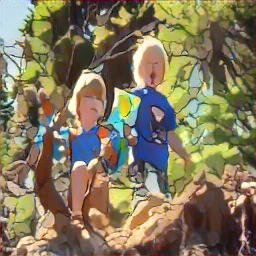

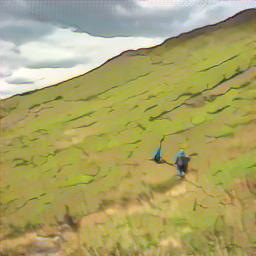

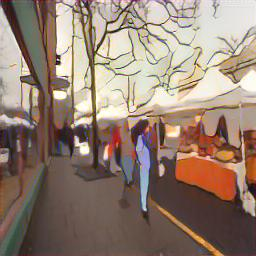

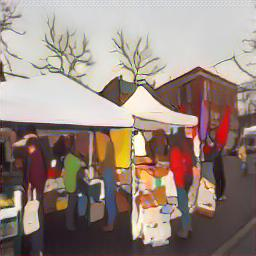

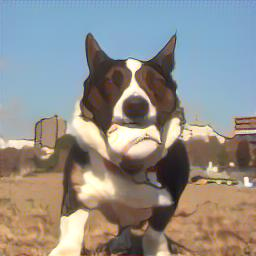

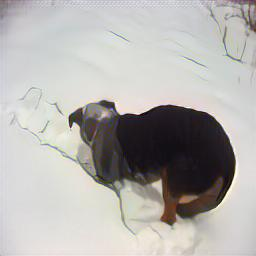

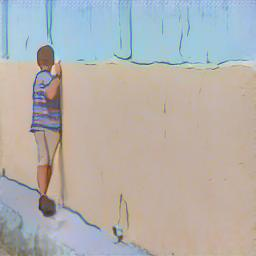

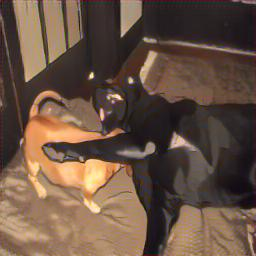

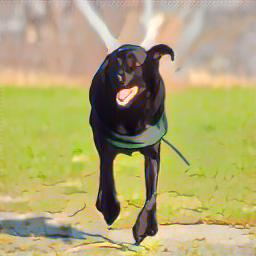

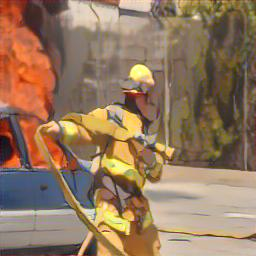

In [11]:
from IPython.display import Image, display
import os

output_folder = '/content/cartoonized_final'
images = sorted([os.path.join(output_folder, f) for f in os.listdir(output_folder)[:10]])

print("Previewing first 10 cartoonized images:")
for img_path in images:
    display(Image(img_path))